In [18]:
# Direct wrappers
#
# https://tslearn.readthedocs.io/en/latest/gen_modules/tslearn.clustering.html#module-tslearn.clustering
# https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.clustering.k_medoids.TimeSeriesKMedoids.html#sktime.clustering.k_medoids.TimeSeriesKMedoids


import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

import random

from timex import lmm_v1, lmm_v2

# feature: addition of interpolation, smoothing and resolution selection
# feature: possibility to combine different clustering methods
# 
from timex.clustering import model_based_clustering # model-based clustering
from timex.clustering import distance_based_clustering # distance-based clustering
from timex.clustering import feature_based_clustering # feature-based clustering
from timex.clustering import meta_clustering # meta algorithms, to combine the different methods


from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score


In [ ]:
AKI_PATH = os.environ['AKI_PATH_NEW']
os.chdir(AKI_PATH)

ts_data = pd.read_parquet("data_preparation_DV_final_for_LCMM_19785AKIpatients_FU7-3650d_SW365d_TR90d_13032025.parquet")
ts_data = ts_data.assign(ID=ts_data.ID.astype('int64'))

TEST = False

In [31]:
# X = [n_ts, sz, dim]
# if there is no interpolation we assume that the time dimension is the second one
# i.e. we have at least 2 dimensions

ts_data = ts_data.rename(columns={"Time_since_index_AKI_days": "Time_days"})

In [32]:
ts_data = ts_data[['Time_days', 'eGFR_int', 'ID']]

In [33]:
if TEST:
    test_selection = random.choices(ts_data.ID.unique().tolist(), k=500)
else:
    test_selection = ts_data.ID.unique().tolist()

In [40]:
clusters_8_timexCustom_outwards = model_based_clustering.clustering_mm(ts_data.loc[ts_data.ID.isin(test_selection)], 
                                                              'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=6, 
                                    spline_degree=3,
                                    how='normal', 
                                    num_samples=1500,
                                    direction='outwards',
                                    normalize=True)


Running LMM splitter..


sample: 100%|██████████| 2000/2000 [00:14<00:00, 141.03it/s, 63 steps of size 1.03e-01. acc. prob=0.93]


cl pos: 61
cl neg: 61
# series: 492, remaining: 370, RMSE_p: 0.14646682143211365, RMSE_n: 0.2948841154575348
Running LMM splitter..


\\DS.UMCUTRECHT.NL\DATA\LAB\laupodteam\AIOS\Bram\production\TimEx\src\timex\clustering\model_based_clustering.py:381: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  remaining['series_idx'] = remaining[series_col].map(id_map)
sample: 100%|██████████| 2000/2000 [00:11<00:00, 174.12it/s, 31 steps of size 1.58e-01. acc. prob=0.91]


cl pos: 61
cl neg: 61
# series: 370, remaining: 248, RMSE_p: 0.4365396201610565, RMSE_n: 0.537324845790863
Running LMM splitter..


sample: 100%|██████████| 2000/2000 [00:06<00:00, 309.01it/s, 31 steps of size 1.96e-01. acc. prob=0.88]


cl pos: 61
cl neg: 61
# series: 248, remaining: 128, RMSE_p: 0.5825482606887817, RMSE_n: 0.6104422211647034
Running LMM splitter..


sample: 100%|██████████| 2000/2000 [00:04<00:00, 446.59it/s, 31 steps of size 1.25e-01. acc. prob=0.90]


cl pos: 61
cl neg: 61
# series: 128, remaining: 35, RMSE_p: 0.48001325130462646, RMSE_n: 0.58349609375
Assigned 8 clusters, assigning remaning 35 series to remainder clusters


In [41]:
clusters_8_timexCustom_inwards = model_based_clustering.clustering_mm(ts_data.loc[ts_data.ID.isin(test_selection)], 
                                                              'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=6, 
                                    spline_degree=3,
                                    how='normal', 
                                    num_samples=1500,
                                    direction='inwards',
                                    normalize=True)


Running LMM splitter..


sample: 100%|██████████| 2000/2000 [00:14<00:00, 138.27it/s, 63 steps of size 1.03e-01. acc. prob=0.93]
\\DS.UMCUTRECHT.NL\DATA\LAB\laupodteam\AIOS\Bram\production\TimEx\src\timex\clustering\model_based_clustering.py:381: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  remaining['series_idx'] = remaining[series_col].map(id_map)


cl pos: 61
cl neg: 61
# series: 492, remaining: 370, RMSE_p: 0.7670004963874817, RMSE_n: 0.8896617889404297
Running LMM splitter..


sample: 100%|██████████| 2000/2000 [00:32<00:00, 61.18it/s, 255 steps of size 6.52e-02. acc. prob=0.95]


cl pos: 61
cl neg: 61
# series: 370, remaining: 255, RMSE_p: 0.6951978206634521, RMSE_n: 0.8817893862724304
Running LMM splitter..


sample: 100%|██████████| 2000/2000 [00:05<00:00, 339.45it/s, 15 steps of size 2.75e-01. acc. prob=0.88]


cl pos: 61
cl neg: 61
# series: 255, remaining: 173, RMSE_p: 0.6308156251907349, RMSE_n: 0.7739725708961487
Running LMM splitter..


sample: 100%|██████████| 2000/2000 [00:05<00:00, 388.66it/s, 15 steps of size 2.78e-01. acc. prob=0.90]


cl pos: 61
cl neg: 61
# series: 173, remaining: 68, RMSE_p: 0.5505715012550354, RMSE_n: 0.6247310042381287
Assigned 8 clusters, assigning remaning 68 series to remainder clusters


In [42]:
clusters_8_mm_slope = model_based_clustering.clustering_mm(ts_data.loc[ts_data.ID.isin(test_selection)], 
                                                                            'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=6, 
                                    spline_degree=3, 
                                    how='slope',
                                    num_samples=1500,
                                    normalize=True)

sample: 100%|██████████| 2000/2000 [00:25<00:00, 78.66it/s, 31 steps of size 1.37e-01. acc. prob=0.83] 


In [43]:
clusters_8_mm_rec = model_based_clustering.clustering_mm(ts_data.loc[ts_data.ID.isin(test_selection)], 
                                                                            'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=6, 
                                    spline_degree=3, 
                                    how='random_effect_clustering',
                                    num_samples=1500,
                                    num_warmup=500,
                                    normalize=True)

sample: 100%|██████████| 2000/2000 [00:22<00:00, 88.30it/s, 31 steps of size 1.24e-01. acc. prob=0.87] 


In [44]:
clusters_8_mm_ric = model_based_clustering.clustering_mm(ts_data.loc[ts_data.ID.isin(test_selection)], 
                                                                            'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=6, 
                                    spline_degree=3, 
                                    how='random_intercept_clustering',
                                    num_samples=1500,
                                    num_warmup=500,
                                    normalize=True)

sample: 100%|██████████| 2000/2000 [00:06<00:00, 288.73it/s, 15 steps of size 2.77e-01. acc. prob=0.88]


In [34]:
clusters_8_lmm = model_based_clustering.clustering_lmm(ts_data.loc[ts_data.ID.isin(test_selection)], 'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=8, 
                                    spline_degree=4, 
                                    num_samples=2000,
                                    num_warmup=500,
                                    discrete=False, # use Gumbel to make the sampling differentiable
                                    num_chains=1,
                                    vi = False,
                                    tau = 10,
                                    normalize=True, 
                                    adaptive_spline=True)

Characteristics of B_obs
min max cond#
0.0 1.0 91.35208
Defining kernel...
Init sampler...
Start sampler...


sample: 100%|██████████| 2500/2500 [02:39<00:00, 15.72it/s, 63 steps of size 6.74e-02. acc. prob=0.87]

Start posterior draws...


In [35]:
clusters_8_lmm_vi = model_based_clustering.clustering_lmm(ts_data.loc[ts_data.ID.isin(test_selection)], 'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=8, 
                                    spline_degree=3, 
                                    num_steps=5000,
                                    discrete=False, # use Gumbel to make the sampling differentiable
                                    vi = True,
                                    tau_search = False,
                                    tau = 10,
                                    normalize=True, 
                                    adaptive_spline=True)

100%|██████████| 5000/5000 [00:11<00:00, 448.56it/s, init loss: 89524.7656, avg. loss [4751-5000]: 12741.5723]


(500, 492, 8)


In [59]:
sum([len(c) for c in clusters_8_timexCustom_outwards])

523

In [ ]:
LOL = { 'lmm_vi': [i for i,c in enumerate(clusters_8_lmm_vi) for _c in c],
        'lmm':[i for i,c in enumerate(clusters_8_lmm) for _c in c],
        'mm_ric':[i for i,c in enumerate(clusters_8_mm_ric) for _c in c],
        'mm_rec':[i for i,c in enumerate(clusters_8_mm_rec) for _c in c], 
        # 'mm_slope':[i for i,c in enumerate(clusters_8_mm_slope) for _c in c],    
        # 'mm_inw':[i for i,c in enumerate(clusters_8_timexCustom_inwards) for _c in c], 
        # 'mm_out':[i for i,c in enumerate(clusters_8_timexCustom_outwards) for _c in c]
}

# get stats
res = []
for k,v1 in LOL.items():
    for l,v2 in LOL.items():
        res.append({
            'm1': k,
            'm2': l, 
            'ami': adjusted_mutual_info_score(v1,v2), 
            'ari': adjusted_rand_score(v1,v2)
            }) 
        


In [62]:
pd.DataFrame(res)

,m1,m2,ami,ari
0,lmm_vi,lmm_vi,1.000000,1.000000
1,lmm_vi,lmm,0.621896,0.441262
2,lmm_vi,mm_ric,0.654536,0.485063
3,lmm_vi,mm_rec,0.668111,0.541152
4,lmm,lmm_vi,0.621896,0.441262
5,lmm,lmm,1.000000,1.000000
6,lmm,mm_ric,0.715685,0.501761
7,lmm,mm_rec,0.678473,0.515057
8,mm_ric,lmm_vi,0.654536,0.485063
9,mm_ric,lmm,0.715685,0.501761


In [37]:
res_list = []
for clnum, idlist in enumerate(clusters_8_lmm):
    for id in idlist:
        res_list.append({
            'clusters_8_lmm': clnum, 
            'ID': id
        })

ts_data = pd.merge(ts_data, pd.DataFrame(res_list), how='left', on='ID')

#####################

res_list = []
for clnum, idlist in enumerate(clusters_8_lmm_vi):
    for id in idlist:
        res_list.append({
            'clusters_8_lmm_vi': clnum, 
            'ID': id
        })

ts_data = pd.merge(ts_data, pd.DataFrame(res_list), how='left', on='ID')



In [38]:
ts_data = ts_data.fillna(-1)

<Axes: xlabel='Time_days', ylabel='eGFR_int'>

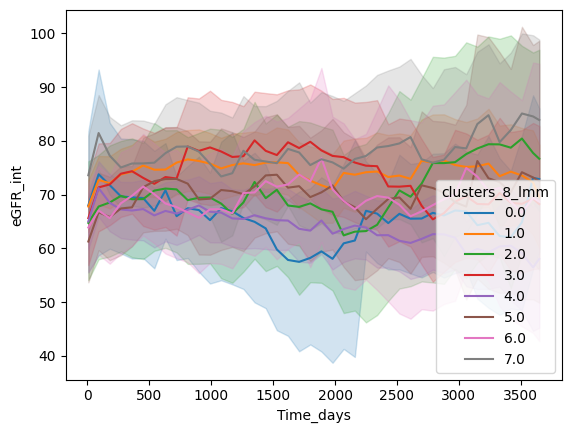

In [39]:
sns.lineplot(ts_data[ts_data.ID.isin(test_selection)], x='Time_days', y='eGFR_int', 
             hue='clusters_8_lmm', palette='tab10')

In [ ]:
num_plots_per_clusters = 100

cmap_ = plt.get_cmap('tab10', len(clusters_8))
cluster_colors = {c: cmap_(c) for c in range(len(clusters_8))}

fig, ax = plt.subplots(figsize=(18, 8))

for ck, cl in enumerate(clusters_8):
    for sid in random.choices(cl, k=num_plots_per_clusters):
        sub = ts_data[ts_data['ID'] == sid]
        ax.plot(sub['Time_days'], sub['eGFR_int'], lw=2, label=ck, color=cluster_colors[ck], alpha=0.1)
ax.set_title('Timeseries by Predicted Cluster')
ax.set_xlabel('Time')
ax.set_ylabel('Value')
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize='small')